# Results



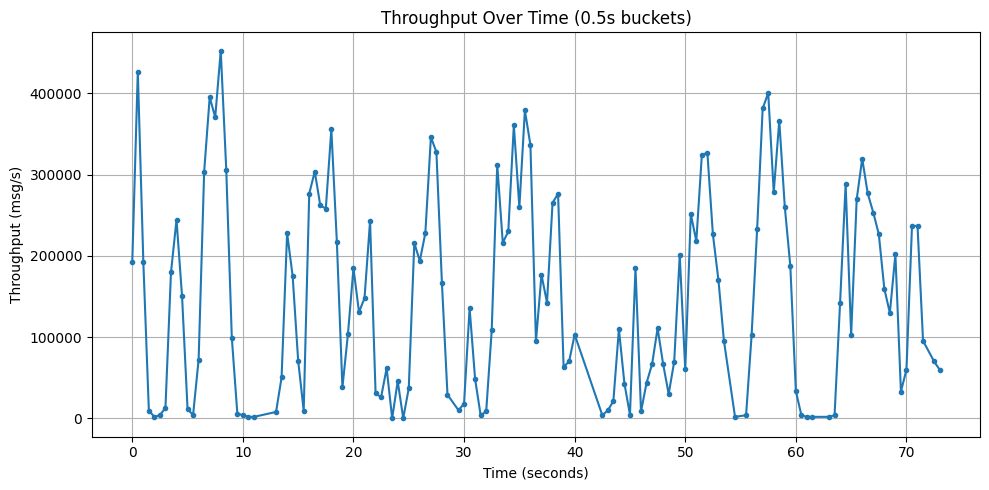

In [2]:
import csv
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt

with open("../client-part2/results/metrics.csv") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

# Parse timestamps and find the start time
times = [datetime.fromisoformat(r["Timestamp"]) for r in rows]
start = min(times)

# Bucket into 0.5-second intervals
BUCKET_SIZE = 0.5
buckets = defaultdict(int)
for t in times:
    bucket = (t - start).total_seconds() // BUCKET_SIZE * BUCKET_SIZE
    buckets[bucket] += 1

# Throughput = messages in bucket / bucket size
x = sorted(buckets.keys())
y = [buckets[b] / BUCKET_SIZE for b in x]

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker="o", markersize=3)
plt.xlabel("Time (seconds)")
plt.ylabel("Throughput (msg/s)")
plt.title(f"Throughput Over Time ({BUCKET_SIZE}s buckets)")
plt.grid(True)
plt.tight_layout()
plt.savefig("./throughput-max.png")
plt.show()